In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import numpy as np
import albumentations as A

import warnings

warnings.filterwarnings(
    "ignore",
    message="Gradients do not exist for variables",
    module="keras.src.optimizers.base_optimizer",
)

from pathlib import Path
from typing import Sequence

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from agx_core.transforms import BrightnessAndContrast, Deskew


class UnlabeledImageDataset(Dataset):
    def __init__(self, root_dir: Path, cond_shape: Sequence[int], transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.cond_shape = cond_shape
        # Get list of all image file names in the folder
        self.image_files = list(root_dir.glob("*.bmp"))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        image = Image.open(img_name).convert("L")

        if self.transform:
            image = self.transform(image=np.array(image))
            image = image["image"][..., np.newaxis]

        condition = np.ones(self.cond_shape, dtype=np.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        image = torch.tensor(image, device=device)
        return (image, torch.tensor(condition, device=device)), image


# def train_transforms(img_size, mean=[0.7], std=[0.4]):
def train_transforms(img_size, mean=[0.5], std=[0.5]):
    return A.Compose(
        [
            Deskew(),
            BrightnessAndContrast(),
            A.InvertImg(1),
            A.Resize(img_size, img_size),
            A.Affine(scale=(0.9, 0.95), rotate=(-90, 90), shear=(5, 5), p=0.5),
            A.RandomRotate90(0.5),
            A.RandomBrightnessContrast(
                contrast_range=(-0.2, 0.2), brightness_range=(-0.5, 0.5), p=0.5
            ),
            A.GaussianBlur(blur_range=(1, 3), p=0.3),
            A.Normalize(mean=mean, std=std),
        ]
    )


# def valid_transforms(img_size, mean=[0.7], std=[0.4]):
def valid_transforms(img_size, mean=[0.5], std=[0.5]):
    return A.Compose(
        [
            Deskew(),
            BrightnessAndContrast(),
            A.InvertImg(1),
            A.Resize(img_size, img_size),
            A.Normalize(mean=mean, std=std),
        ]
    )

In [2]:
from agx_core.models.reversed_autoencoder import MobileNetV3SmallEncoder, MobileNetV3SmallDecoder
from agx_torch.models.reversed_autoencoder.model import ReversedAutoencoder
from agx_torch.models.reversed_autoencoder.layers import Reparameterization

img_size = 224
res = img_size // 2**5

img_shape = (None, img_size, img_size, 1)
cond_shape = (None, res, res, 1)

rep = Reparameterization()
enc = MobileNetV3SmallEncoder(latent_size=512, progressive=True)
dec = MobileNetV3SmallDecoder(target_shape=img_shape[1:], progressive=True)

print(img_shape, cond_shape)

(None, 224, 224, 1) (None, 7, 7, 1)


In [3]:
# import keras
# x = keras.random.normal((1, 224, 224, 1))
# c = keras.random.normal((1, 7, 7, 1))

# x_resized = keras.ops.image.resize(x, enc.current_input_size())

# (mean, logvar), embeds = enc([x_resized, c])
# z = rep([mean, logvar])

In [4]:
train_path = Path("../data/products/LaTuaPastaGlassJars/Clean/train/")
valid_path = Path("../data/products/LaTuaPastaGlassJars/Clean/val/")
test_path = Path("../data/products/LaTuaPastaGlassJars/Test/images/train/")

ds_train = UnlabeledImageDataset(
    train_path, transform=train_transforms(img_size), cond_shape=cond_shape[1:]
)
ds_valid = UnlabeledImageDataset(
    valid_path, transform=valid_transforms(img_size), cond_shape=cond_shape[1:]
)
ds_test = UnlabeledImageDataset(
    test_path, transform=valid_transforms(img_size), cond_shape=cond_shape[1:]
)

loader_train = DataLoader(ds_train, batch_size=8, shuffle=True)
loader_valid = DataLoader(ds_valid, batch_size=8)

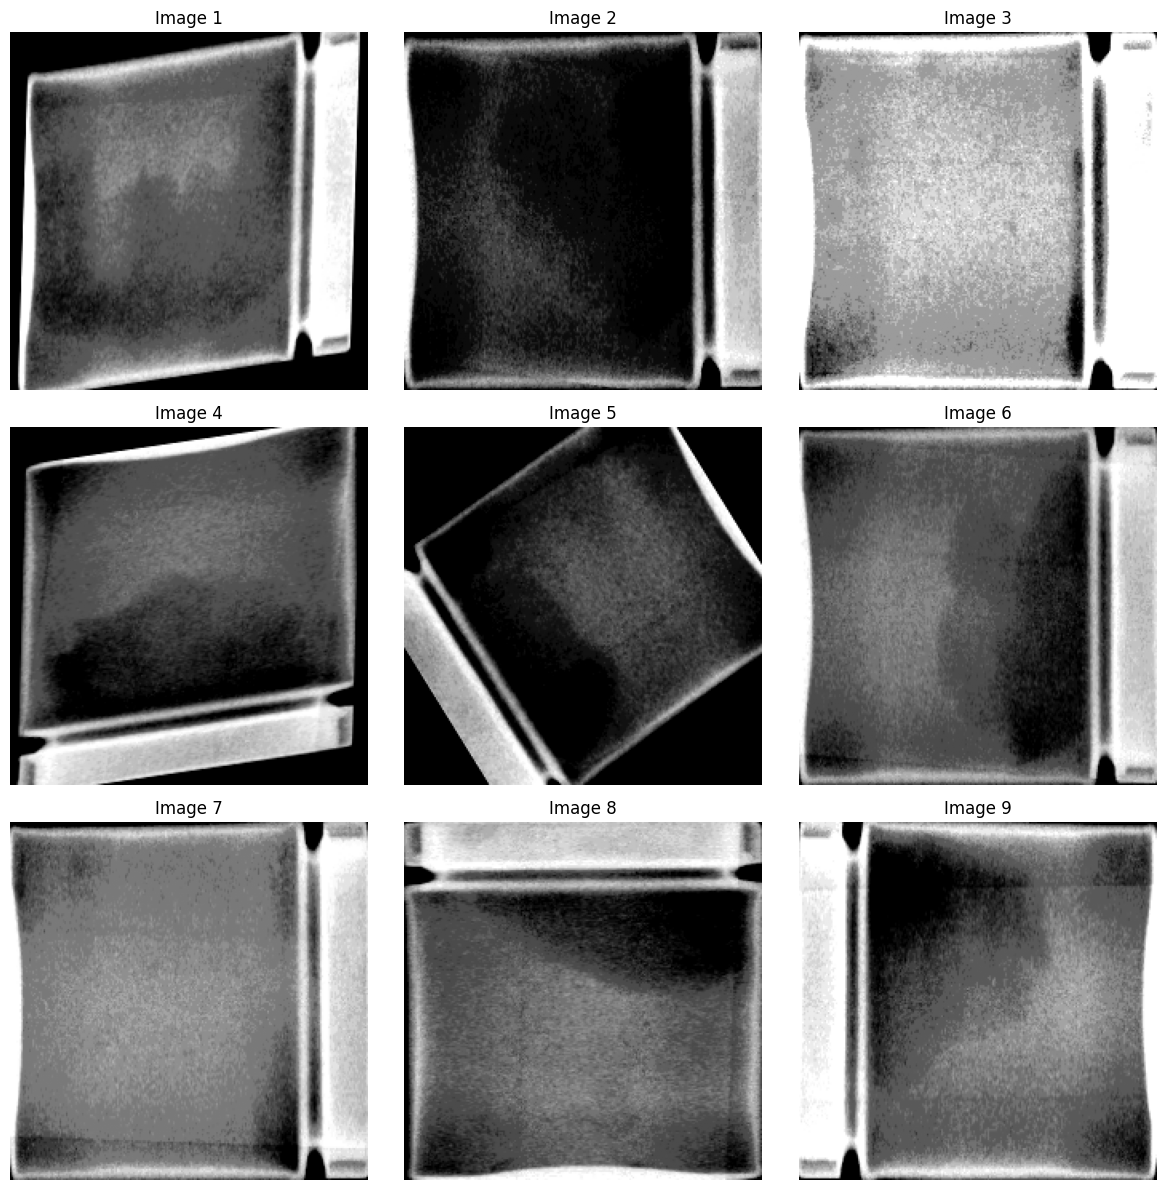

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, ax in enumerate(axes.flat):
    X, y = ds_train[idx]
    image = X[0].cpu().numpy()
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Image {idx + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

from agx_core.models.reversed_autoencoder.callbacks import (
    AdversarialEquilibriumCallback,
    ProgressiveGrowingCallback,
)

ra = ReversedAutoencoder(enc, dec, beta_kld=0.1, freeze_backbone=False)
ra.build([img_shape, cond_shape])
ra.compile(Adam(learning_rate=1e-6), Adam(learning_rate=1e-4))

callbacks = [
    AdversarialEquilibriumCallback(0.5, -0.2),
    ProgressiveGrowingCallback(1000, 1000),
    ModelCheckpoint(
        filepath="ra_mbnetv3.best.keras",
        monitor="val_loss_rec",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
]

ra.summary()

Model: "reversed_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mbnetv3_encoder                 │ (((None, 7, 7, 512),   │     1,529,528 │
│ (MobileNetV3SmallEncoder)       │ (None, 7, 7, 512)),    │               │
│                                 │ [(None, 7, 7, 96)])    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mbnetv3_decoder                 │ (None, 14, 14, 1)      │     1,568,413 │
│ (MobileNetV3SmallDecoder)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reparameterization              │ (None, 7, 7, 512)      │             0 │
│ (Reparameterization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,157,019 (23.49 MB)

 Trainable params: 3,071,797 (11.72 MB)

 Non-trainable params: 26,144 (102.12 KB)

 Optimizer params: 3,059,078 (11.67 MB)

In [ ]:
history = ra.fit(loader_train, validation_data=loader_valid, epochs=600, callbacks=callbacks, verbose=2)


[ProGrow] Starting progressive training at stage 4 — output (224, 224)
Epoch 201/600



Epoch 201: val_loss_rec did not improve from 0.09900
25/25 - 13s - 511ms/step - diff_kld: -8.4950e-02 - elbo_fake: -3.3228e-02 - elbo_real: -3.7265e-01 - elbo_rec: -3.3100e-02 - expelbo_fake: 0.9675 - expelbo_rec: 0.9676 - kld_fake: 0.3322 - kld_real: 0.4171 - kld_rec: 0.3308 - loss_dec: 2.2228 - loss_embed: 1.8586 - loss_enc: 1.3402 - loss_rec: 0.3309 - val_diff_kld: -3.3510e-02 - val_elbo_fake: -2.1681e-03 - val_elbo_real: -1.9746e-01 - val_elbo_rec: -2.1658e-03 - val_expelbo_fake: 0.9978 - val_expelbo_rec: 0.9978 - val_kld_fake: 0.0217 - val_kld_real: 0.0552 - val_kld_rec: 0.0216 - val_loss_dec: 1.7422 - val_loss_embed: 1.5428 - val_loss_enc: 1.1949 - val_loss_rec: 0.1919
Epoch 202/600

[Equilibrium] State: warmup → both (EMA diff_kld=-0.1138, steps_paused=50)

Epoch 202: val_loss_rec did not improve from 0.09900
25/25 - 14s - 563ms/step - diff_kld: -5.3711e-02 - elbo_fake: -3.4606e-02 - elbo_real: -3.4590e-01 - elbo_rec: -3.3443e-02 - expelbo_fake: 0.9662 - expelbo_rec: 0.9673 - k

KeyboardInterrupt: 

In [8]:
ra.save("ra_mbnetv3.model.keras")

In [10]:
import pandas as pd

df = pd.DataFrame.from_dict(history.history)

hist_file = Path("history.csv")
if hist_file.exists():
    hist = pd.read_csv(hist_file)
    df.index += len(hist)
    hist = pd.concat([hist, df])
    # hist.to_csv(hist_file, index=False)
else:
    df.to_csv(hist_file, index=False)
    hist = df
hist.tail()


,diff_kld,elbo_fake,elbo_real,elbo_rec,expelbo_fake,expelbo_rec,kld_fake,kld_real,kld_rec,loss_dec,...,val_elbo_rec,val_expelbo_fake,val_expelbo_rec,val_kld_fake,val_kld_real,val_kld_rec,val_loss_dec,val_loss_embed,val_loss_enc,val_loss_rec
195,-2.337584e+05,-0.132525,-23376.277344,-1.074686,0.980253,0.957532,1.288519,2.337597e+05,10.511211,23378.697266,...,-0.003713,0.996640,0.996294,0.033459,0.045088,0.035579,1.723235,1.533043,1.182527,0.181889
196,-2.099602e+06,-0.011800,-209960.703125,-2894.805664,0.988367,0.980188,0.117418,2.099603e+06,28947.998047,209963.015625,...,-0.001885,0.998104,0.998116,0.018934,0.045088,0.018817,1.718199,1.521923,1.191502,0.189382
197,-5.463045e+00,-0.030691,-0.897542,-0.031556,0.969907,0.969168,0.306782,5.769824e+00,0.314853,2.825790,...,-0.001932,0.998059,0.998070,0.019363,0.046637,0.019279,1.723763,1.521726,1.197454,0.195185
198,-1.237798e-01,-0.033605,-0.372961,-0.033150,0.967098,0.967500,0.335901,4.596806e-01,0.331227,2.262971,...,-0.002160,0.997829,0.997842,0.021671,0.049303,0.021560,1.736080,1.533589,1.197503,0.195199
199,-8.881747e-02,-0.033870,-0.372023,-0.033494,0.966881,0.967217,0.338555,4.273728e-01,0.334606,2.267711,...,-0.002496,0.997492,0.997507,0.025053,0.052231,0.024910,1.750620,1.547509,1.197442,0.195193


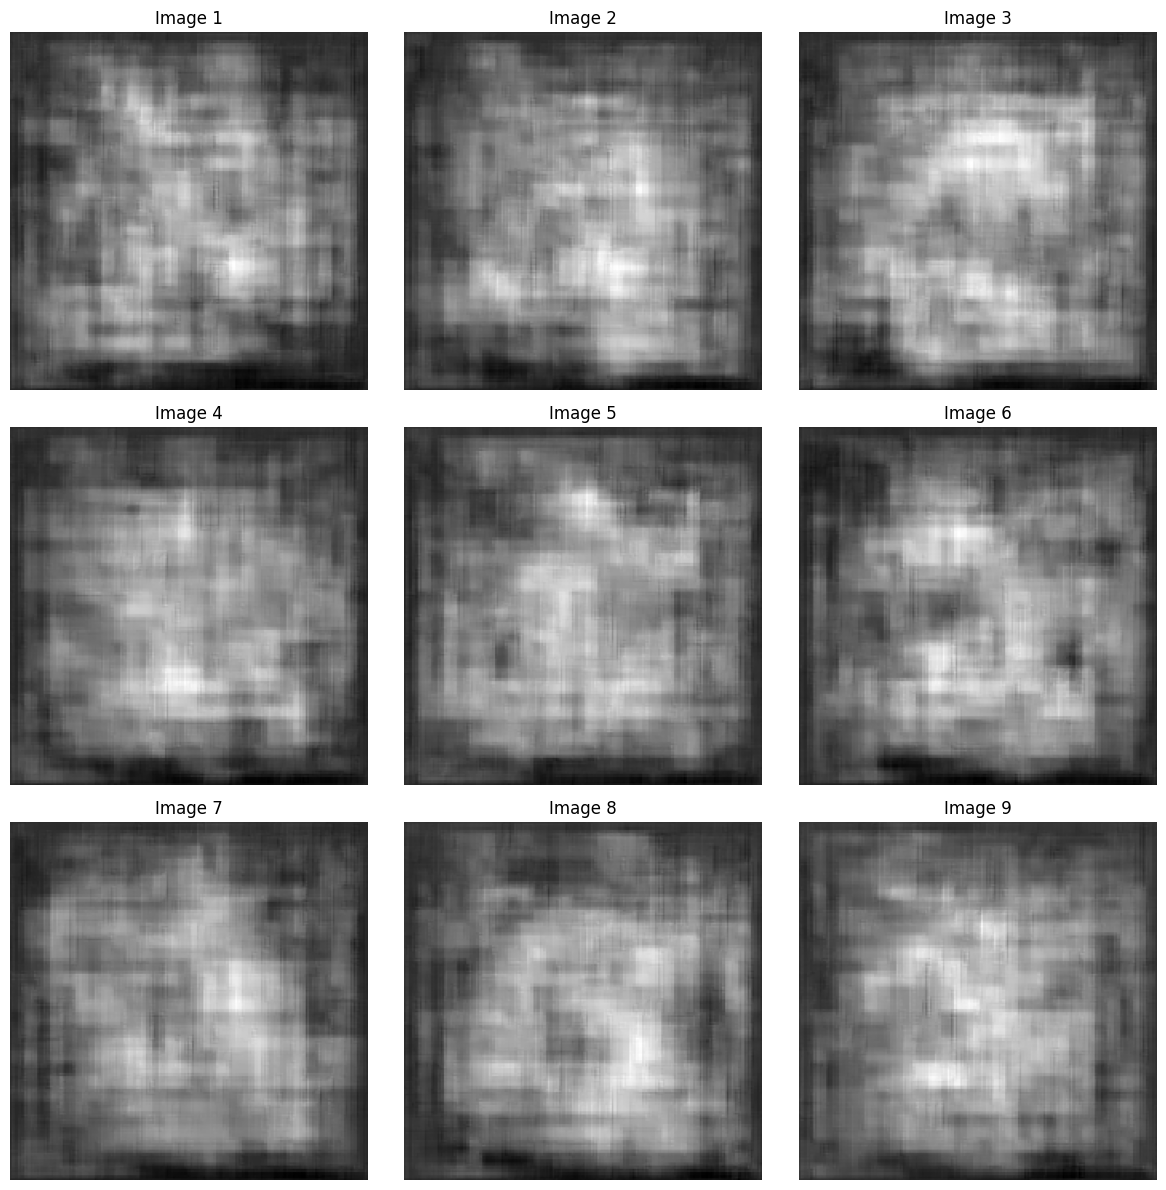

In [20]:
import keras
import matplotlib.pyplot as plt

ra_best = keras.models.load_model("ra_mbnetv3.best.keras", safe_mode=False)
while not ra_best.decoder.is_fully_grown:
    ra_best.encoder.grow()
    ra_best.encoder.alpha = 1
    ra_best.decoder.grow()
    ra_best.decoder.alpha = 1


fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, ax in enumerate(axes.flat):
    (I, C), y = ds_train[idx]
    rec = ra_best([I[np.newaxis, ...], C[np.newaxis, ...]])
    ax.imshow(rec.cpu().detach().numpy()[0], cmap="gray")
    ax.set_title(f"Image {idx + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

<Axes: >

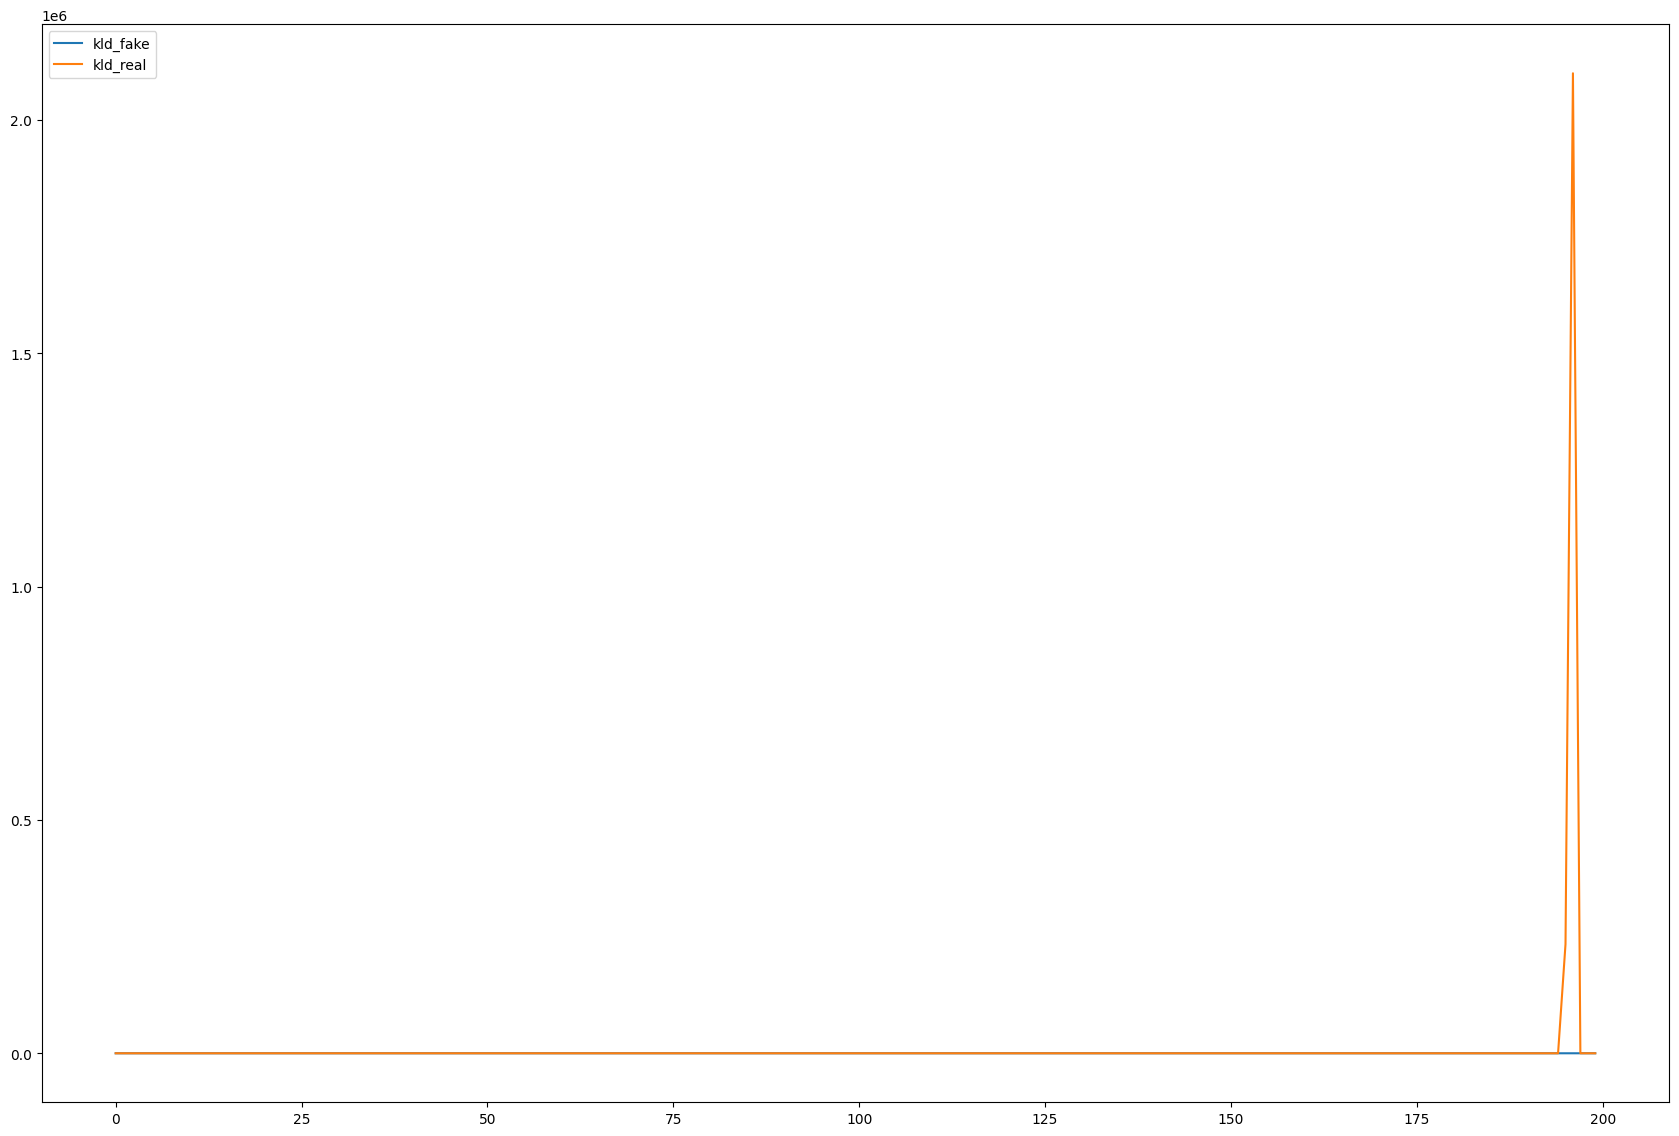

In [24]:
import pandas as pd

fig, ax = plt.subplots(figsize=(21, 14))

# Adjust val_loss_embed, forgot to update validation scaling
hist[["kld_fake", "kld_real"]].plot(ax=ax)

In [25]:
with torch.device("cpu"):
    ra_best.eval()
    I = torch.rand((1, *img_shape[1:]))
    C = torch.rand((1, *cond_shape[1:]))

    torch.onnx.export(
        ra_best,
        ([I, C],),
        "model.onnx",
        input_names=["image", "condition"],
        output_names=["reconstruction"],
    )

[torch.onnx] Obtain model graph for `<ReversedAutoencoder name=reversed_autoencoder, built=True>` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `<ReversedAutoencoder name=reversed_autoencoder, built=True>` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `<ReversedAutoencoder name=reversed_autoencoder, built=True>` with `torch.export.export(..., strict=True)`...
[torch.onnx] Obtain model graph for `<ReversedAutoencoder name=reversed_autoencoder, built=True>` with `torch.export.export(..., strict=True)`... ❌


TorchExportError: Failed to export the model with torch.export. [96mThis is step 1/3[0m of exporting the model to ONNX. Next steps:
- Modify the model code for `torch.export.export` to succeed. Refer to https://pytorch.org/docs/stable/generated/exportdb/index.html for more information.
- Debug `torch.export.export` and submit a PR to PyTorch.
- Create an issue in the PyTorch GitHub repository against the [96m*torch.export*[0m component and attach the full error stack as well as reproduction scripts.

## Exception summary

<class 'torch.fx.experimental.symbolic_shapes.GuardOnDataDependentSymNode'>: 

The error above occurred when calling torch.export.export. If you would like to view some more information about this error, and get a list of all other errors that may occur in your export call, you can replace your `export()` call with `draft_export()`.

(Refer to the full stack trace above for more information.)

In [ ]:
import matplotlib.pyplot as plt

from agx_core.helpers import _channel_axis
from keras import ops

def kl_divergence(mean, logvar):
    return 0.5 * ops.sum(
        ops.square(mean) + ops.exp(logvar) - logvar - 1.0,
        axis=_channel_axis(),
    )

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for idx in range(5):
    (I, C), y = ds_test[idx]
    rec = ra_best([I[np.newaxis, ...], C[np.newaxis, ...]]).cpu().detach().numpy()[0][0]
    (mean, logvar), _ = ra_best.encoder([I[np.newaxis, ...], C[np.newaxis, ...]])
    kld = kl_divergence(mean, logvar).cpu().detach().numpy()[0]
    I = I[0].cpu().detach().numpy()
    D = np.square(I - rec)
    axes.flat[3 * idx].imshow(rec, cmap="gray")
    axes.flat[3 * idx + 1].imshow(I, cmap="gray")
    axes.flat[3 * idx + 2].imshow(D, cmap="gray")
    axes.flat[3 * idx].axis("off")
    axes.flat[3 * idx + 1].axis("off")
    axes.flat[3 * idx + 2].axis("off")

plt.tight_layout()
plt.show()